# Blood Rheology: Modified t-ETV Model (Mt-ETV) with Logarithmic Free Energy

## Overview

The **Modified thermodynamic Extended Thixotropic Vector (Mt-ETV) model** emerges from a rigorous tensorial reformulation of the original t-ETV framework, with a primary objective: ensuring **thermodynamic consistency** through an explicit Helmholtz free-energy formulation.

### Key Conceptual Differences from t-ETV

The Mt-ETV model retains the same three structural variables as t-ETV:
1. **Cellular conformation tensor** ($\mathbf{c}^C$): Describes the deformation and orientation of individual red blood cells
2. **Rouleaux conformation tensor** ($\mathbf{c}^R$): Describes the deformation and orientation of cell aggregates
3. **Structure parameter** ($\lambda$): Quantifies the degree of aggregation, ranging from 0 (fully dispersed) to 1 (fully aggregated)

### Free Energy with Logarithmic Form

The Helmholtz free energy includes a logarithmic term that provides natural bounds on $\lambda$:

$$\hat{f}_c = \frac{G_C}{2\rho}\left[\text{tr}(\mathbf{c}^C) - \log|\mathbf{c}^C|\right] - \frac{G_R}{2m\rho}\lambda^m + \Phi(\lambda e^{-I_R})$$

where $\Phi(\xi) = \frac{G_R}{2m\rho} a \xi^m \log(\xi^m)$ with $a = \frac{e^{-3m}}{3m+1}$ and $\xi = \lambda e^{-I_R}$.

## Workflow

1. Define symbolic variables
2. Construct viscosity and kinematic setup
3. Define Helmholtz free energy with logarithmic form
4. Derive constitutive relations
5. Lambdify for numerical integration
6. Run simulations
7. Visualize and compare

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from extras import show 
sp.init_printing()
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsfonts}\usepackage{amsmath}"
})

print("Symbolic computation engine initialized.")

Symbolic computation engine initialized.


In [2]:
# Independent variable: time
t = sp.symbols('t', real=True)

# Imposed shear rate (constant in simple shear startup)
gamma0 = sp.symbols(r'\dot{\gamma_0}', real=True)

print("Independent variables:")
print(f"  Time: t")
print(f"  Shear rate: γ̇₀ (constant for simple shear startup)")

Independent variables:
  Time: t
  Shear rate: γ̇₀ (constant for simple shear startup)


In [3]:
# Cellular conformation tensor components (symmetric, 2D block + diagonal)
cCxx, cCxy, cCyy, cCzz = sp.symbols(r'c^C_{xx} c^C_{xy} c^C_{yy} c^C_{zz}', real=True)

# Rouleaux conformation tensor components (symmetric, 2D block + diagonal)
cRxx, cRxy, cRyy, cRzz = sp.symbols(r'c^R_{xx} c^R_{xy} c^R_{yy} c^R_{zz}', real=True)

# Structural variable (aggregation degree)
lam = sp.symbols(r'\lambda', positive=True)

# Bundle state variables for convenient handling
state_syms = (cCxx, cCxy, cCyy, cCzz, cRxx, cRxy, cRyy, cRzz, lam)
state_names = ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']

print(f"State variables (9 total): {state_names}")
print(f"  Cellular tensor: 4 components (c11, c12, c22, c33)")
print(f"  Rouleaux tensor: 4 components (c11, c12, c22, c33)")
print(f"  Structural variable: λ (scalar)")

State variables (9 total): ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']
  Cellular tensor: 4 components (c11, c12, c22, c33)
  Rouleaux tensor: 4 components (c11, c12, c22, c33)
  Structural variable: λ (scalar)


In [4]:
# Cellular contribution parameters
G_C, muC0, muCinf, tauC = sp.symbols(r'G_C \mu_{0-C} \mu_{\infty-C} \tau_C', positive=True)

# Rouleaux and structural parameters (Mt-ETV version)
G_R, tau_R, tau_lam = sp.symbols(r'G_R \tau_R \tau_\lambda', positive=True)

# Power-law exponent for stress dependence on λ
m = sp.symbols('m', positive=True)

# Physical parameters
rho, Temp = sp.symbols('rho T', positive=True)

# Parameter for the logarithmic free energy function Φ(ξ)
a_param = sp.symbols('a', real=True)

# Bundle parameter symbols
param_syms = (G_C, muC0, muCinf, tauC, G_R, tau_R, tau_lam, m, rho, Temp, a_param)
param_names = ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'tau_R', 'tau_lam', 'm', 'rho', 'T', 'a']

print(f"Material parameters (11 total): {param_names}")
print(f"\nParameter categories:")
print(f"  Cellular: G_C, muC0, muCinf, tauC")
print(f"  Rouleaux & structure: G_R, tau_R, tau_lam")
print(f"  Microstructure: m, a_param")
print(f"  Physical: rho, T")

Material parameters (11 total): ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'tau_R', 'tau_lam', 'm', 'rho', 'T', 'a']

Parameter categories:
  Cellular: G_C, muC0, muCinf, tauC
  Rouleaux & structure: G_R, tau_R, tau_lam
  Microstructure: m, a_param
  Physical: rho, T


In [5]:
# Cellular viscosity: Cross model (shear-rate dependent)
eta_C = muCinf + (muC0 - muCinf) / (1 + tauC*gamma0)

print("Cellular viscosity (Cross model):")
show(eta_C)

Cellular viscosity (Cross model):


<IPython.core.display.Math object>

In [6]:
# Velocity gradient tensor for simple shear: v = (γ̇₀·y, 0, 0)
nabla_v = sp.Matrix([
    [0, gamma0, 0],
    [0, 0, 0],
    [0, 0, 0]
])

# Rate-of-strain tensor: D = (∇v + ∇v†)/2
Dten = (nabla_v + nabla_v.T) / 2

print("Velocity gradient ∇v:")
show(nabla_v)
print("\nRate-of-strain tensor D:")
show(Dten)

Velocity gradient ∇v:


<IPython.core.display.Math object>


Rate-of-strain tensor D:


<IPython.core.display.Math object>

In [7]:
# Full 3×3 conformation tensors (symmetric structure)
cC = sp.Matrix([
    [cCxx, cCxy, 0],
    [cCxy, cCyy, 0],
    [0, 0, cCzz]
])

cR = sp.Matrix([
    [cRxx, cRxy, 0],
    [cRxy, cRyy, 0],
    [0, 0, cRzz]
])

print("Cellular conformation tensor c^C:")
show(cC)
print("\nRouleaux conformation tensor c^R:")
show(cR)

Cellular conformation tensor c^C:


<IPython.core.display.Math object>


Rouleaux conformation tensor c^R:


<IPython.core.display.Math object>

In [8]:
# Upper-convected derivative: (∇v)†·c + c·∇v
upper_conv_C = nabla_v.T @ cC + cC @ nabla_v
upper_conv_R = nabla_v.T @ cR + cR @ nabla_v

print("Upper-convected contribution to dc^C/dt:")
show(upper_conv_C)
print("\nUpper-convected contribution to dc^R/dt:")
show(upper_conv_R)

Upper-convected contribution to dc^C/dt:


<IPython.core.display.Math object>


Upper-convected contribution to dc^R/dt:


<IPython.core.display.Math object>

In [8]:
# Stress components
tau_xy_C = -eta_C*gamma0 - G_C*cCxy
tau_xy_R = -G_R*lam**m*cRxy
tau_xy = tau_xy_C + tau_xy_R

print("Stress components defined")
show(tau_xy)

Stress components defined


<IPython.core.display.Math object>

In [9]:
# Inverse traces (with singularity protection)
eps = 1e-12
det_cC2_safe = det_cC2 + eps
det_cR2_safe = det_cR2 + eps

trinv_2x2_C = (cCxx + cCyy) / det_cC2_safe
trinv_2x2_R = (cRxx + cRyy) / det_cR2_safe

trinvC = trinv_2x2_C + 1/(cCzz + eps)
trinvR = trinv_2x2_R + 1/(cRzz + eps)

# Entropy generation terms (Mt-ETV)
# Cellular contribution
Sdot_C = -(G_C**2 / (2*rho*eta_C)) * (trC + trinvC - 6)

# Rouleaux contribution
Sdot_R = -(G_R*lam**m / (2*tau_R)) * (trR + trinvR - 6)

# Structural contribution: -M(λ)[∂f̂_c/∂λ]²
Sdot_lam = -M_lam * dfdl**2

# Total entropy generation rate
Sdot_gen = -(rho/Temp) * (Sdot_C + Sdot_R + Sdot_lam)

Sdot_terms = (Sdot_C, Sdot_R, Sdot_lam)

print("Entropy generation defined")

Entropy generation defined


In [10]:
# Construct the right-hand side state vector
rhs_syms_raw = sp.Matrix([
    dc_C_dict[cCxx],
    dc_C_dict[cCxy],
    dc_C_dict[cCyy],
    dc_C_dict[cCzz],
    dc_R_dict[cRxx],
    dc_R_dict[cRxy],
    dc_R_dict[cRyy],
    dc_R_dict[cRzz],
    dlam_dt
])

# State variable names
state_names = ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']
param_names = ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'tau_R', 'tau_lam', 'm', 'tau_aggr', 'd', 'rho', 'T']

# Lambdify: state vars + shear rate + parameters
_args = (cCxx, cCxy, cCyy, cCzz, cRxx, cRxy, cRyy, cRzz, lam, gamma0) + param_syms

rhs_func_raw = sp.lambdify(_args, rhs_syms_raw, modules='numpy')
tauxy_func = sp.lambdify(_args, tau_xy, modules='numpy')
sdot_gen_func = sp.lambdify(_args, Sdot_gen, modules='numpy')
sdot_terms_func = sp.lambdify(_args, Sdot_terms, modules='numpy')

# WRAPPER con protección numérica
def rhs_func(*args):
    """Wrapper with NaN/Inf protection"""
    result = rhs_func_raw(*args)
    result = np.array(result, dtype=float).flatten()
    
    # Detectar NaN/Inf y reemplazar con derivada cero
    bad_idx = ~np.isfinite(result)
    if np.any(bad_idx):
        print(f"Warning: NaN/Inf detected at indices {np.where(bad_idx)[0]}")
        result[bad_idx] = 0.0
    
    # Limitar magnitud de derivadas
    max_deriv = 100.0
    result = np.clip(result, -max_deriv, max_deriv)
    
    return result

print("Lambdification complete with protection wrapper")
print(f"State variables: {state_names}")
print(f"Parameters: {param_names}")

Lambdification complete with protection wrapper
State variables: ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']
Parameters: ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'tau_R', 'tau_lam', 'm', 'tau_aggr', 'd', 'rho', 'T']


In [11]:
# Material parameters (Mt-ETV with logarithmic free energy)
param_dict = {
    'G_C': 0.5471,          # Pa
    'muC0': 0.0082,         # Pa·s
    'muCinf': 0.0034,       # Pa·s
    'tauC': 0.0474,         # s
    'G_R': 0.1552,          # Pa
    'tau_R': 1.5,           # s (constant, not lambda-dependent)
    'm': 1.5,               # -
    'tau_lam': 0.2,         # s (reduced from 1.98 for Mt-ETV)
    'tau_aggr': 1.17e-2,    # s
    'd': 0.5,               # -
    'rho': 1060.0,          # kg/m³
    'T': 310.0,             # K
}

# Convert to ordered tuple
params_tuple = tuple(param_dict[name] for name in param_names)

# Initial condition
y0 = np.array([1.0, 0.0, 1.0, 1.0,      # c^C
               1.0, 0.0, 1.0, 1.0,       # c^R
               1.0])                     # lambda

# Output directories
OUTPUT_DIR = 'data/Mt-ETV-Log'
FIGURE_DIR = 'figs/Mt-ETV-Log'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# Shear rates
gamma0_list = [2.0, 5.0, 10.0]

# Integration settings
INTEGRATOR_OPTS = {'method': 'Radau', 'rtol': 1e-8, 'atol': 1e-10}

print("Material parameters and setup complete")
print(f"Output: {OUTPUT_DIR}")
print(f"Figures: {FIGURE_DIR}")

Material parameters and setup complete
Output: data/Mt-ETV-Log
Figures: figs/Mt-ETV-Log


In [12]:
def rhs_wrapper(t, y_state, gamma0_val, params):
    """Wrapper to call rhs_func with correct argument order"""
    return np.array(rhs_func(*y_state, gamma0_val, *params), dtype=float).flatten()

In [13]:
# Añade después de "print("Running startup flow...")"

# Usar método más tolerante
INTEGRATOR_OPTS_SAFE = {
    'method': 'BDF',  # Cambiar de Radau a BDF
    'rtol': 1e-6, 
    'atol': 1e-8,
    'max_step': 0.01  # Limitar tamaño de paso
}

# Usar esta en lugar de INTEGRATOR_OPTS

In [14]:
t_startup_span = (0.0, 10.0)
t_startup_eval = np.concatenate([[0.0], np.logspace(-3, np.log10(10.0), 1000)])

startup_results = {}

print("Running startup flow (Mt-ETV logarithmic)...")
for g0 in gamma0_list:
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, g0, params_tuple),
        t_startup_span,
        y0,
        t_eval=t_startup_eval,
        **INTEGRATOR_OPTS
    )
    
    tauxy = np.array([tauxy_func(*sol.y[:, k], g0, *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sdot_gen_func(*sol.y[:, k], g0, *params_tuple) for k in range(len(sol.t))])
    
    startup_results[g0] = {'t': sol.t, 'y': sol.y, 'tauxy': tauxy, 'sgen': sgen}
    print(f"  ✓ γ̇₀ = {g0} 1/s")

startup_data = {'t': t_startup_eval}
for g0 in gamma0_list:
    r = startup_results[g0]
    startup_data[f'lam_g{g0}'] = r['y'][8, :]
    startup_data[f'tauxy_g{g0}'] = r['tauxy']
    startup_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'startup.npz'), **startup_data)
print(f"Saved to {OUTPUT_DIR}/startup.npz\n")

Running startup flow (Mt-ETV logarithmic)...


<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in scalar power
  return array([[G_C*(1 - Dummy_49)/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1))], [-Dummy_48*G_C/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1)) + Dummy_49*Dummy_57], [2*Dummy_48*Dummy_57 + G_C*(1 - Dummy_47)/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1))], [G_C*(1 - Dummy_46)/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1))], [(1 - Dummy_45)/Dummy_52], [-Dummy_44/Dummy_52 + Dummy_45*Dummy_57], [2*Dummy_44*Dummy_57 + (1 - Dummy_43)/Dummy_52], [(1 - _Dummy_42)/Dummy_52], [-2*Dummy_44*Dummy_56*Dummy_57 - 2*rho*(-1/2*Dummy_56**m*G_R/(Dummy_56*rho) + (1/2)*G_R*(Dummy_56*exp(_Dummy_42 + Dummy_43 + Dummy_45)/((_Dummy_42 + 1.0e-14)*(Dummy_43*Dummy_45 - Dummy_44**2 + 1.0e-14)))**(2*m)*exp(-3*m)*exp(-_Dummy_42 - Dummy_43 - Dummy_45)*exp(_Dummy_42 + Dummy_43 + Dummy_45)/(Dummy_56*rho*(3*m + 1)*((Dummy_56*exp(_Dummy_42 + Dummy_43 + Dummy_45)/((_Dummy_42 + 1.0e-14)

  ✓ γ̇₀ = 2.0 1/s
  ✓ γ̇₀ = 5.0 1/s
  ✓ γ̇₀ = 10.0 1/s
Saved to data/Mt-ETV-Log/startup.npz



<lambdifygenerated-1>:2: RuntimeWarning: overflow encountered in scalar power
  return array([[G_C*(1 - Dummy_49)/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1))], [-Dummy_48*G_C/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1)) + Dummy_49*Dummy_57], [2*Dummy_48*Dummy_57 + G_C*(1 - Dummy_47)/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1))], [G_C*(1 - Dummy_46)/(Dummy_54 + (-Dummy_54 + Dummy_55)/(Dummy_53*Dummy_57 + 1))], [(1 - Dummy_45)/Dummy_52], [-Dummy_44/Dummy_52 + Dummy_45*Dummy_57], [2*Dummy_44*Dummy_57 + (1 - Dummy_43)/Dummy_52], [(1 - _Dummy_42)/Dummy_52], [-2*Dummy_44*Dummy_56*Dummy_57 - 2*rho*(-1/2*Dummy_56**m*G_R/(Dummy_56*rho) + (1/2)*G_R*(Dummy_56*exp(_Dummy_42 + Dummy_43 + Dummy_45)/((_Dummy_42 + 1.0e-14)*(Dummy_43*Dummy_45 - Dummy_44**2 + 1.0e-14)))**(2*m)*exp(-3*m)*exp(-_Dummy_42 - Dummy_43 - Dummy_45)*exp(_Dummy_42 + Dummy_43 + Dummy_45)/(Dummy_56*rho*(3*m + 1)*((Dummy_56*exp(_Dummy_42 + Dummy_43 + Dummy_45)/((_Dummy_42 + 1.0e-14)*(Dum

Saved to figs/Mt-ETV-Log/startup.png


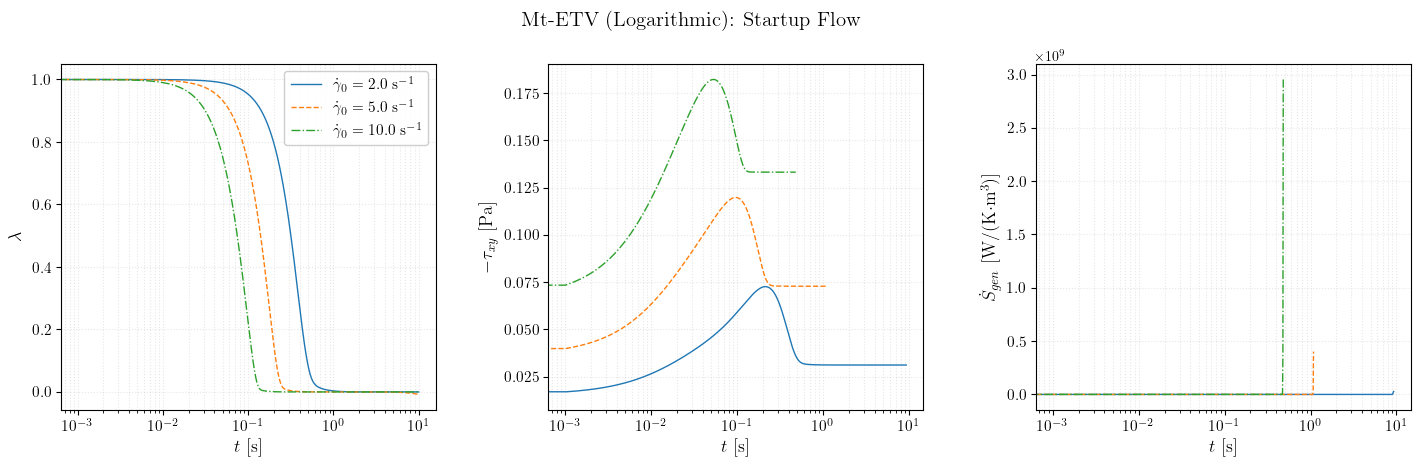

In [16]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
linestyles = ['-', '--', '-.']
linewidths = [1, 1, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = startup_results[g0]
    label = fr'$\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'
    
    axes[0].plot(r['t'], r['y'][8, :], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K$\cdot$m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('Mt-ETV (Logarithmic): Startup Flow', fontsize=15, fontweight='bold', y=1.00)
plt.subplots_adjust(left=0.08, right=0.98, wspace=0.3)
plt.savefig(os.path.join(FIGURE_DIR, 'startup.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/startup.png")
plt.show()

In [17]:
t_relax_span = (0.0, 20.0)
t_relax_eval = np.concatenate([[0.0], np.logspace(-3, np.log10(20.0), 999)])
t_relax_eval = np.sort(np.unique(np.clip(t_relax_eval, 0, 20.0)))

relax_results = {}

print("Running stress relaxation (Mt-ETV logarithmic)...")
for g0 in gamma0_list:
    y_init = startup_results[g0]['y'][:, -1]
    
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, 0.0, params_tuple),
        t_relax_span,
        y_init,
        t_eval=t_relax_eval,
        **INTEGRATOR_OPTS
    )
    
    tauxy = np.array([tauxy_func(*sol.y[:, k], 0.0, *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sdot_gen_func(*sol.y[:, k], 0.0, *params_tuple) for k in range(len(sol.t))])
    
    relax_results[g0] = {'t': sol.t, 'y': sol.y, 'tauxy': tauxy, 'sgen': sgen}
    print(f"  ✓ γ̇₀ = {g0} 1/s (relaxation)")

relax_data = {'t': t_relax_eval}
for g0 in gamma0_list:
    r = relax_results[g0]
    relax_data[f'lam_g{g0}'] = r['y'][8, :]
    relax_data[f'tauxy_g{g0}'] = r['tauxy']
    relax_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'relaxation.npz'), **relax_data)
print(f"Saved to {OUTPUT_DIR}/relaxation.npz\n")

Running stress relaxation (Mt-ETV logarithmic)...
  ✓ γ̇₀ = 2.0 1/s (relaxation)
  ✓ γ̇₀ = 5.0 1/s (relaxation)
  ✓ γ̇₀ = 10.0 1/s (relaxation)
Saved to data/Mt-ETV-Log/relaxation.npz



Saved to figs/Mt-ETV-Log/relaxation.png


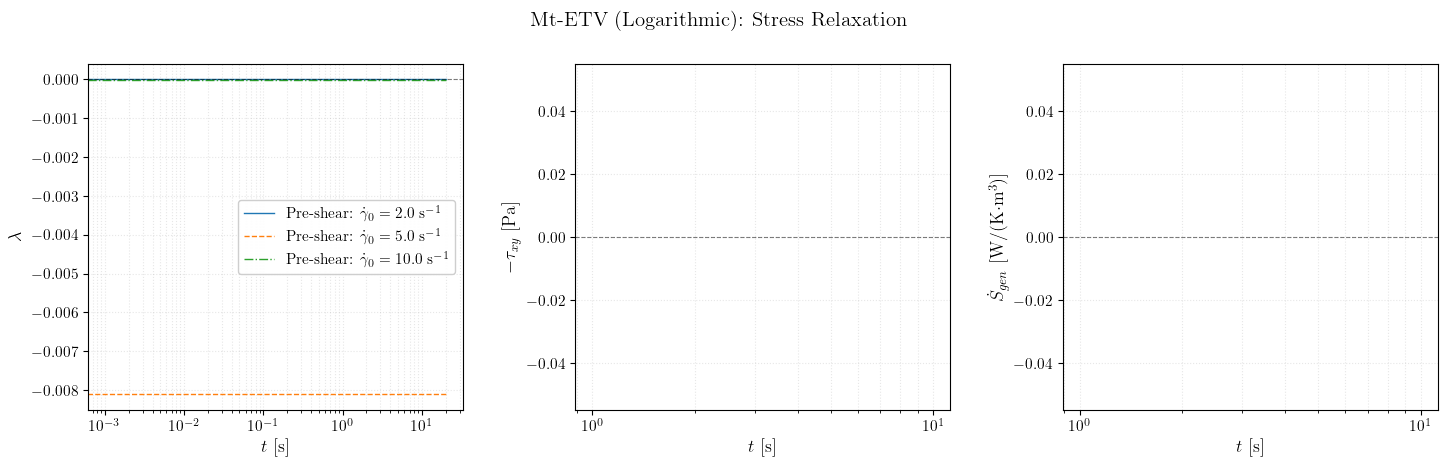

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = relax_results[g0]
    label = fr'Pre-shear: $\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'
    
    axes[0].plot(r['t'], r['y'][8, :], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K$\cdot$m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('Mt-ETV (Logarithmic): Stress Relaxation', fontsize=15, fontweight='bold', y=1.00)
plt.subplots_adjust(left=0.08, right=0.98, wspace=0.3)
plt.savefig(os.path.join(FIGURE_DIR, 'relaxation.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/relaxation.png")
plt.show()

In [19]:
t_rev = 10.0
t_reversal_span = (0.0, 20.0)
t_before = np.logspace(-3, np.log10(t_rev), 500)
t_after = t_rev + np.logspace(-3, np.log10(10.0), 500)
t_reversal_eval = np.concatenate([t_before, t_after])
t_reversal_eval = np.sort(np.unique(np.clip(t_reversal_eval, 0, 20.0)))

reversal_results = {}

print("Running shear rate reversal (Mt-ETV logarithmic)...")
for g0 in gamma0_list:
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, g0 if t < t_rev else -g0, params_tuple),
        t_reversal_span,
        y0,
        t_eval=t_reversal_eval,
        **INTEGRATOR_OPTS
    )
    
    gamma_history = np.where(sol.t < t_rev, g0, -g0)
    tauxy = np.array([tauxy_func(*sol.y[:, k], gamma_history[k], *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sdot_gen_func(*sol.y[:, k], gamma_history[k], *params_tuple) for k in range(len(sol.t))])
    
    mask = sol.t >= t_rev
    reversal_results[g0] = {
        't': sol.t[mask] - t_rev,
        'y': sol.y[:, mask],
        'tauxy': tauxy[mask],
        'sgen': sgen[mask]
    }
    print(f"  ✓ γ̇₀ = {g0} 1/s (reversed at t={t_rev}s)")

reversal_data = {'t': reversal_results[gamma0_list[0]]['t']}
for g0 in gamma0_list:
    r = reversal_results[g0]
    reversal_data[f'lam_g{g0}'] = r['y'][8, :]
    reversal_data[f'tauxy_g{g0}'] = r['tauxy']
    reversal_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'reversal.npz'), **reversal_data)
print(f"Saved to {OUTPUT_DIR}/reversal.npz\n")

Running shear rate reversal (Mt-ETV logarithmic)...
  ✓ γ̇₀ = 2.0 1/s (reversed at t=10.0s)
  ✓ γ̇₀ = 5.0 1/s (reversed at t=10.0s)
  ✓ γ̇₀ = 10.0 1/s (reversed at t=10.0s)
Saved to data/Mt-ETV-Log/reversal.npz



Saved to figs/Mt-ETV-Log/reversal.png


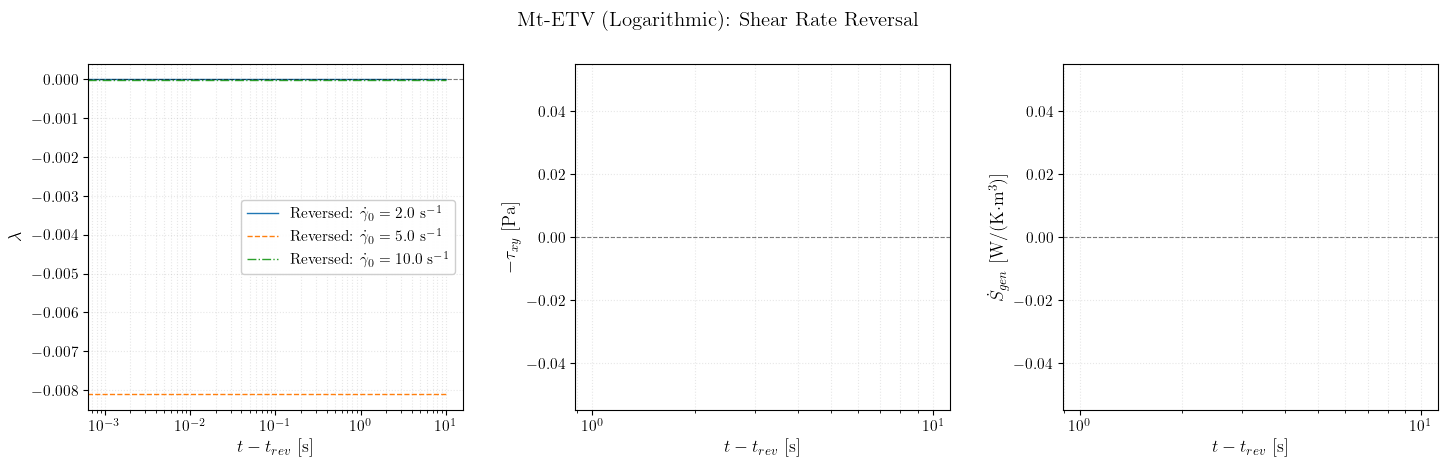

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = reversal_results[g0]
    label = fr'Reversed: $\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'
    
    axes[0].plot(r['t'], r['y'][8, :], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K$\cdot$m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t - t_{{rev}}$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('Mt-ETV (Logarithmic): Shear Rate Reversal', fontsize=15, fontweight='bold', y=1.00)
plt.subplots_adjust(left=0.08, right=0.98, wspace=0.3)
plt.savefig(os.path.join(FIGURE_DIR, 'reversal.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/reversal.png")
plt.show()